# 3D RM-CLEAN

We'll start with the same synthetic cube as the 3D RM-synth example -- see that page for details -- and run RM-synthesis again here to get the dirty FDF and RMSF cubes.

In [1]:
from __future__ import annotations

import tempfile
from pathlib import Path

import astropy.io.fits as fits
import astropy.units as u
import dask
import matplotlib.pyplot as plt
import numpy as np
import zarr
from astropy.visualization import quantity_support

plt.rcParams["figure.dpi"] = 150

_ = quantity_support()
rng = np.random.default_rng(42)

bw_low = 288
freqs = np.linspace(943.5 - bw_low / 2, 943.5 + bw_low / 2, 36) * u.MHz
freq_hz = freqs.to(u.Hz).value

ny, nx = 32, 32
y_grid, x_grid = np.mgrid[0:ny, 0:nx]
blob_y, blob_x = ny * 0.3, nx * 0.7
rm_map = 80.0 * (x_grid / nx - 0.5) * 2 + 40.0 * np.exp(
    -((x_grid - blob_x) ** 2 + (y_grid - blob_y) ** 2) / (2 * 4.0**2)
)
radius_grid = np.hypot(x_grid - blob_x, y_grid - blob_y)
psi0_deg = 30.0
rms_noise = 0.03

In [2]:
from rm_lite.utils.fitting import gaussian
from rm_lite.utils.synthesis import faraday_simple_spectrum

# A single compact polarised source (a 2D Gaussian blob, reusing the existing
# 1D gaussian() on a radial distance grid) on an otherwise unpolarised
# background -- mostly-empty sky is what the noise estimator below needs.
frac_pol_map = gaussian(radius_grid, amplitude=0.6, mean=0.0, fwhm=6.0)

stokes_q = np.empty((freq_hz.size, ny, nx), dtype=np.float32)
stokes_u = np.empty((freq_hz.size, ny, nx), dtype=np.float32)
for j in range(ny):
    for i in range(nx):
        complex_spectrum = faraday_simple_spectrum(
            freq_hz, frac_pol=frac_pol_map[j, i], psi0_deg=psi0_deg, rm_radm2=rm_map[j, i]
        )
        stokes_q[:, j, i] = complex_spectrum.real + rng.normal(0, rms_noise, freq_hz.size)
        stokes_u[:, j, i] = complex_spectrum.imag + rng.normal(0, rms_noise, freq_hz.size)

tmpdir = Path(tempfile.mkdtemp())


def write_stokes_fits(path: Path, data: np.ndarray, stokes: int) -> None:
    header = fits.Header()
    header["CTYPE1"] = "RA---SIN"
    header["CTYPE2"] = "DEC--SIN"
    header["CTYPE3"] = "FREQ"
    header["CRVAL3"] = freq_hz[0]
    header["CDELT3"] = float(np.diff(freq_hz)[0])
    header["CRPIX3"] = 1.0
    header["CUNIT3"] = "Hz"
    header["CTYPE4"] = "STOKES"
    header["CRVAL4"] = stokes
    header["CDELT4"] = 1.0
    header["CRPIX4"] = 1.0
    fits.PrimaryHDU(data=data[np.newaxis, ...], header=header).writeto(path, overwrite=True)


stokes_q_fits = tmpdir / "cutout.q.fits"
stokes_u_fits = tmpdir / "cutout.u.fits"
write_stokes_fits(stokes_q_fits, stokes_q, stokes=2)
write_stokes_fits(stokes_u_fits, stokes_u, stokes=3)

In [3]:
from rm_lite.tools_3d.rmsynth import rmsynth_3d
from rm_lite.utils.dask_io import estimate_channel_noise_mad, read_fits_cube_dask

q_dask, _ = read_fits_cube_dask(stokes_q_fits, target_chunk_bytes=32 * 1024)
u_dask, _ = read_fits_cube_dask(stokes_u_fits, target_chunk_bytes=32 * 1024)

channel_noise = estimate_channel_noise_mad(q_dask, u_dask)
weight_arr = 1.0 / channel_noise**2

synth = rmsynth_3d(
    q_dask, u_dask, freq_hz, weight_arr=weight_arr, phi_max_radm2=150.0, d_phi_radm2=10.0
)
synth.fdf_dirty_cube

dask.array<_synth_block, shape=(31, 32, 32), dtype=complex128, chunksize=(31, 15, 15), chunktype=numpy.ndarray>

Now run 3D RM-CLEAN with `rmclean_3d`. The Hogbom clean loop (`rm_lite.utils.clean.rmclean`) is inherently per-pixel, so it runs once per spatial chunk via `dask.delayed`. It returns four outputs (clean FDF, model FDF, residual FDF, iteration count) from that one call -- they're split out of the same delayed computation rather than re-running the clean loop per output.

Unlike the 1D convenience wrapper `run_rmclean_from_synth`, `rmclean_3d` takes raw flux thresholds directly rather than deriving an auto-mask/auto-threshold itself -- a whole cube doesn't have one noise value. We derive it ourselves here, the same way the 1D wrapper does, from `compute_theoretical_noise` fed by the robust per-channel noise and weights from above.

In [4]:
from rm_lite.tools_3d.rmclean import rmclean_3d

help(rmclean_3d)

Help on function rmclean_3d in module rm_lite.tools_3d.rmclean:

rmclean_3d(fdf_dirty_cube: 'da.Array', rmsf_cube: 'da.Array', phi_arr_radm2: 'NDArray[np.float64]', phi_double_arr_radm2: 'NDArray[np.float64]', fwhm_rmsf_radm2: 'float', mask: 'float', threshold: 'float', max_iter: 'int' = 1000, gain: 'float' = 0.1, log_level: 'int' = 40) -> 'RMClean3DResults'
    Run RM-CLEAN on chunked dirty FDF and RMSF cubes.

    Args:
        fdf_dirty_cube (da.Array): Dirty FDF cube, shape (n_phi, ny, nx),
            chunked spatially only (as produced by `rm_lite.tools_3d.rmsynth.rmsynth_3d`).
        rmsf_cube (da.Array): RMSF cube, shape (n_phi_double, ny, nx), with the
            same spatial chunking as `fdf_dirty_cube`.
        phi_arr_radm2 (NDArray[np.float64]): Faraday depth values in rad/m^2.
        phi_double_arr_radm2 (NDArray[np.float64]): Double-length Faraday depth
            values in rad/m^2, for the RMSF.
        fwhm_rmsf_radm2 (float): RMSF FWHM, shared by every pixel (3D R

In [5]:
from rm_lite.utils.synthesis import compute_theoretical_noise

theoretical_noise = compute_theoretical_noise(
    complex_pol_error=channel_noise + 1j * channel_noise,
    weight_arr=weight_arr,
)

auto_mask, auto_threshold = 8.0, 2.0
mask = auto_mask * theoretical_noise.fdf_error_noise
threshold = auto_threshold * theoretical_noise.fdf_error_noise

clean = rmclean_3d(
    synth.fdf_dirty_cube,
    synth.rmsf_cube,
    synth.phi_arr_radm2,
    synth.phi_double_arr_radm2,
    synth.fwhm_rmsf_radm2,
    mask=mask,
    threshold=threshold,
)
clean.iter_count_map

dask.array<concatenate, shape=(32, 32), dtype=int64, chunksize=(15, 15), chunktype=numpy.ndarray>

`rmclean_3d` above takes the dirty FDF/RMSF cubes and phi arrays unpacked from `synth` one by one. `rmclean_3d_from_synth` takes the `RMSynth3DResults` itself and unpacks it internally -- mirroring the 1D `run_rmclean_from_synth` convenience -- while still taking `mask`/`threshold` directly, for the same reason `rmclean_3d` does.

In [6]:
from rm_lite.tools_3d.rmclean import rmclean_3d_from_synth

clean_from_synth = rmclean_3d_from_synth(synth, mask=mask, threshold=threshold)
np.array_equal(clean_from_synth.iter_count_map.compute(), clean.iter_count_map.compute())

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

True

Everything is still lazy. Compute all four outputs together with `dask.compute` so the shared per-chunk clean loop only runs once, then compare the dirty and clean peak polarised intensity maps and look at where CLEAN actually did work.

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

[Text(0.5, 1.0, 'CLEAN iterations')]

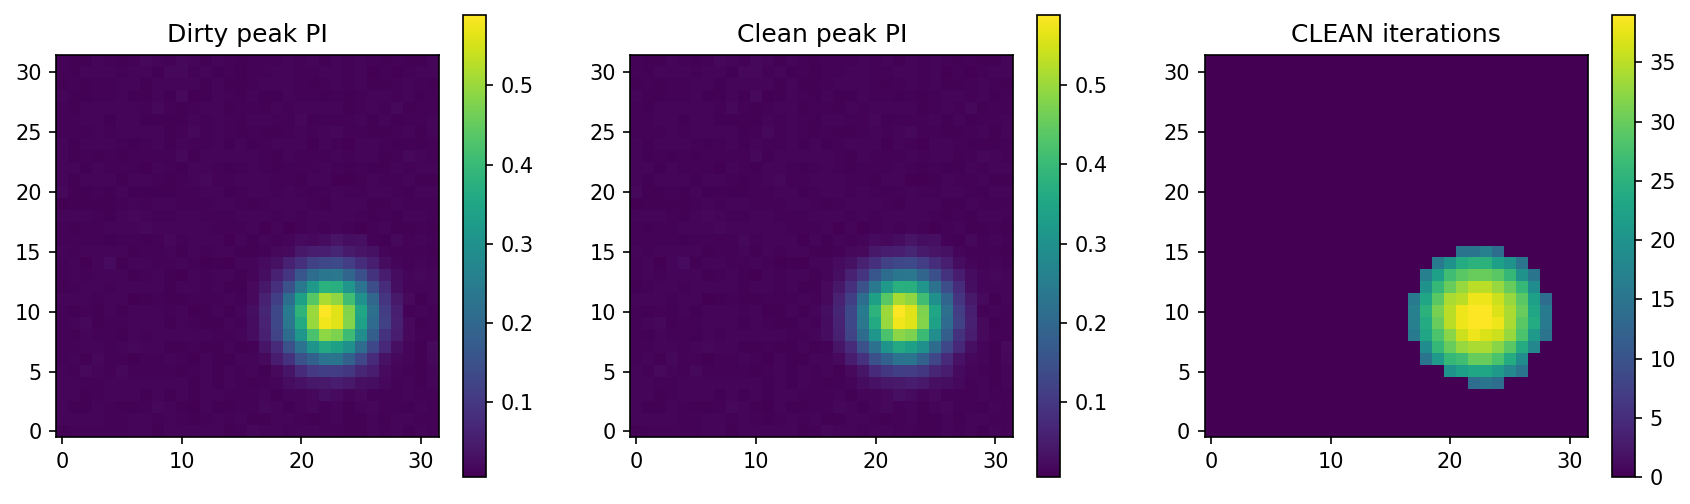

In [7]:
clean_fdf_cube, model_fdf_cube, resid_fdf_cube, iter_count_map = dask.compute(
    clean.clean_fdf_cube,
    clean.model_fdf_cube,
    clean.resid_fdf_cube,
    clean.iter_count_map,
)

dirty_fdf_cube = synth.fdf_dirty_cube.compute()
dirty_pi_map = np.max(np.abs(dirty_fdf_cube), axis=0)
clean_pi_map = np.max(np.abs(clean_fdf_cube), axis=0)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
im0 = axs[0].imshow(dirty_pi_map, origin="lower")
fig.colorbar(im0, ax=axs[0])
axs[0].set(title="Dirty peak PI")
im1 = axs[1].imshow(clean_pi_map, origin="lower")
fig.colorbar(im1, ax=axs[1])
axs[1].set(title="Clean peak PI")
im2 = axs[2].imshow(iter_count_map, origin="lower")
fig.colorbar(im2, ax=axs[2])
axs[2].set(title="CLEAN iterations")

## Serialisation: zarr vs FITS

As with the RM-synth outputs, the clean/model/residual FDF cubes are complex -- zarr again is the natural fit, writing lazily chunk by chunk. The iteration-count map is different: it's real-valued (an integer per pixel), so it has no complex-split problem and writes to FITS directly, same as any ordinary 2D image.

In [8]:
from rm_lite.utils.dask_io import write_zarr_group

zarr_store = tmpdir / "rmclean3d.zarr"
write_zarr_group(
    zarr_store,
    {
        "fdf_clean": clean.clean_fdf_cube,
        "fdf_model": clean.model_fdf_cube,
        "fdf_resid": clean.resid_fdf_cube,
        "iter_count": clean.iter_count_map,
    },
)

group = zarr.open(zarr_store)
group["fdf_clean"].shape, group["fdf_clean"].dtype, group["iter_count"].dtype

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

((31, 32, 32), dtype('<c16'), dtype('<i8'))

In [9]:
iter_count_fits = tmpdir / "CLEAN_nIter.fits"
fits.PrimaryHDU(iter_count_map.astype(np.float32)).writeto(iter_count_fits, overwrite=True)

roundtrip = fits.getdata(iter_count_fits)
np.array_equal(roundtrip, iter_count_map.astype(np.float32))

True